# PBC cohort: nested validation, tuning, and explainability

This notebook answers the question `02_modeling.ipynb` leaves open: **is a
single 80/20 test split a defensible number for a 412-row cohort?**

It runs, in order: repeated nested cross-validation
(`src/validation.nested_cv_evaluate`), Harrell's bootstrap optimism correction
(`src/validation.bootstrap_optimism_correction`), Optuna hyperparameter tuning
for the primary comparator (`src/hpo.run_hyperparameter_study`), and SHAP
explanations (`src/explainability.compute_shap_explanations`) for the tuned
model. It closes with the single-split-vs-nested-CV comparison table that is
this project's central empirical claim.

Exploratory research on a historical cohort with no external or temporal
validation: **not for clinical use, not medical advice, not a replacement for
biopsy or clinician assessment**.

**Notebook contract:** every executable cell is immediately followed by a
short discussion of what the output shows, what it means clinically, and what
was decided as a result.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd

_here = Path.cwd().resolve()
PROJECT_ROOT = next(p for p in [_here, *_here.parents]
                    if (p / "src" / "data.py").exists() and (p / "data" / "raw" / "pbc.csv").exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import events_per_variable, load_pbc_data, train_test_split_pipeline
from src.evaluation import binary_metrics, select_operating_threshold
from src.explainability import compute_shap_explanations, plot_shap_summary
from src.hpo import run_hyperparameter_study
from src.modeling import build_named_pipeline
from src.validation import bootstrap_optimism_correction, nested_cv_evaluate

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "pbc.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
frame = load_pbc_data(DATA_PATH)
split = train_test_split_pipeline(frame, test_size=0.2, random_state=41)
MODELS = ("logistic", "random_forest", "hist_gradient_boosting", "lightgbm")
PRIMARY_MODEL = "hist_gradient_boosting"
print(f"Project root: {PROJECT_ROOT}")
print(f"Train rows: {len(split.X_train)}; events-per-variable: {events_per_variable(split.X_train, split.y_binary_train):.2f}")

Project root: /home/datakrdo/Documents/portfolio/cirrhosis
Train rows: 329; events-per-variable: 5.62


This notebook reuses the same production split as `02_modeling.ipynb`
(`train_test_split_pipeline`, cohort-stratified) so its single-split numbers
are directly comparable, then goes further with resampling-based estimators
that use the training fold repeatedly rather than once.

An events-per-variable ratio below 10 means point estimates from any one
split are unstable; before trusting a headline number, that instability has
to be quantified, not assumed away.

All four prespecified models (`logistic`, `random_forest`,
`hist_gradient_boosting`, `lightgbm`) are compared under nested CV and
bootstrap optimism correction; `hist_gradient_boosting` remains the primary
comparator for tuning and SHAP.

In [2]:
nested_results = {}
for name in MODELS:
    nested_results[name] = nested_cv_evaluate(
        split.X_train, split.y_binary_train, name,
        outer_splits=5, outer_repeats=5, inner_splits=3, random_state=41,
    )

nested_auroc = pd.DataFrame({
    name: {
        "mean": res["summary"]["auroc"]["mean"], "std": res["summary"]["auroc"]["std"],
        "ci_low": res["summary"]["auroc"]["ci_95"][0], "ci_high": res["summary"]["auroc"]["ci_95"][1],
    }
    for name, res in nested_results.items()
}).T
print("Nested CV AUROC (5x5 repeated stratified outer folds, inner-CV threshold tuning):")
print(nested_auroc.round(3).to_string())

[I 2026-09-08 22:49:43,035] A new study created in memory with name: no-name-d4754051-415d-4873-b0f0-af83e1c50984


[I 2026-09-08 22:49:43,088] Trial 0 finished with value: 0.693362819664903 and parameters: {'C': 0.01797289837745552, 'splines': True}. Best is trial 0 with value: 0.693362819664903.


[I 2026-09-08 22:49:43,141] Trial 1 finished with value: 0.6955467372134039 and parameters: {'C': 0.0016494814210308672, 'splines': True}. Best is trial 1 with value: 0.6955467372134039.


[I 2026-09-08 22:49:43,194] Trial 2 finished with value: 0.695102375440917 and parameters: {'C': 0.009008517237663088, 'splines': True}. Best is trial 1 with value: 0.6955467372134039.


[I 2026-09-08 22:49:43,245] Trial 3 finished with value: 0.6782820767195767 and parameters: {'C': 0.12413676821551707, 'splines': False}. Best is trial 1 with value: 0.6955467372134039.


...

[I 2026-09-08 23:00:36,554] Trial 6 finished with value: 0.6461588541666666 and parameters: {'n_estimators': 79, 'learning_rate': 0.014595572624752771, 'num_leaves': 25, 'max_depth': 7, 'min_child_samples': 40}. Best is trial 0 with value: 0.6636284722222222.


[I 2026-09-08 23:00:36,976] Trial 7 pruned. 


[I 2026-09-08 23:00:37,385] Trial 8 pruned. 


[I 2026-09-08 23:00:37,590] Trial 9 pruned. 


Nested CV AUROC (5x5 repeated stratified outer folds, inner-CV threshold tuning):
                         mean    std  ci_low  ci_high
logistic                0.701  0.058   0.612    0.814
random_forest           0.697  0.063   0.579    0.816
hist_gradient_boosting  0.655  0.050   0.583    0.738
lightgbm                0.687  0.066   0.556    0.785


Each of the 25 outer folds (5 splits x 5 repeats) holds out roughly 66
rows, fits preprocessing/threshold selection on the remaining training rows
only, and scores the untouched fold; the resulting mean and CI reflect
between-fold variability that a single 83-row test set cannot show.

Repeated resampling is the standard small-sample alternative to a single
holdout in clinical prediction modelling (Steyerberg, *Clinical Prediction
Models*); it trades a single sharp-looking number for an honest, wider one.

These nested-CV means and intervals — not the `02_modeling.ipynb` single-split
numbers — are treated as the headline performance estimates.

In [3]:
optimism_results = {}
for name in MODELS:
    optimism_results[name] = bootstrap_optimism_correction(
        split.X_train, split.y_binary_train, name, n_boot=200, random_state=41,
    )

optimism_table = pd.DataFrame({
    name: {
        "apparent_auroc": res["apparent"]["auroc"],
        "corrected_auroc": res["corrected"]["auroc"],
        "optimism": res["optimism"]["auroc"],
    }
    for name, res in optimism_results.items()
}).T
print("Harrell bootstrap optimism correction (n_boot=200):")
print(optimism_table.round(3).to_string())

Harrell bootstrap optimism correction (n_boot=200):
                        apparent_auroc  corrected_auroc  optimism
logistic                         0.745            0.695     0.050
random_forest                    0.897            0.792     0.105
hist_gradient_boosting           0.834            0.738     0.096
lightgbm                         1.000            0.909     0.091


"Apparent" performance refits each model on 200 bootstrap resamples of
the training data and scores it on that same resample; the gap between
apparent and full-training-set performance estimates how much of the apparent
score is overfitting rather than signal, and that gap is subtracted from the
full-sample score.

Tree ensembles with few effective regularisation constraints can reach
near-perfect apparent AUROC on 329 training rows while generalising far worse
— exactly the failure mode nested CV and optimism correction are designed to
catch.

Apparent, corrected, and nested-CV numbers are reported side by side rather
than the apparent number alone; a large apparent-vs-corrected gap is itself a
finding about the model, not noise to be dismissed.

In [4]:
study = run_hyperparameter_study(
    split.X_train, split.y_binary_train,
    model_name=PRIMARY_MODEL, n_trials=30, random_state=41, cv=3,
)
print(f"Best inner-CV AUROC for {PRIMARY_MODEL} (standalone 3-fold search): {study.best_value:.3f}")
print("Best hyperparameters:", json.dumps(study.best_params, indent=2))
print(f"\nnested_cv_evaluate's own tuned mean (previous cell, tune_hyperparameters=True "
      f"by default): {nested_results[PRIMARY_MODEL]['summary']['auroc']['mean']:.3f}. "
      "This standalone study is a separate, larger (30-trial) search shown for inspection "
      "of the winning hyperparameters; it is not itself an unbiased performance estimate "
      "(it reports the maximum over 30 trials on one CV split), so it is not the number "
      "this project reports as headline performance -- that number comes from the previous "
      "cell, where each outer fold reruns its own smaller (n_trials=10) inner search before "
      "being scored, so the reported mean already prices in the cost of tuning.")

[I 2026-09-09 08:58:44,006] A new study created in memory with name: no-name-72a41fe9-022c-4aa4-b1c1-3a7b7352d5ff


[I 2026-09-09 08:58:44,300] Trial 0 finished with value: 0.6684440928270042 and parameters: {'max_iter': 200, 'max_depth': 2, 'learning_rate': 0.09994007137813693, 'l2_regularization': 0.2173474282237603, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.6684440928270042.


[I 2026-09-09 08:58:44,774] Trial 1 finished with value: 0.7082489451476793 and parameters: {'max_iter': 342, 'max_depth': 3, 'learning_rate': 0.09715804671557356, 'l2_regularization': 4.587239244354484, 'min_samples_leaf': 20}. Best is trial 1 with value: 0.7082489451476793.


[I 2026-09-09 08:58:45,081] Trial 2 finished with value: 0.7100140646976091 and parameters: {'max_iter': 233, 'max_depth': 3, 'learning_rate': 0.018843496726467263, 'l2_regularization': 1.5855523524331532, 'min_samples_leaf': 22}. Best is trial 2 with value: 0.7100140646976091.


[I 2026-09-09 08:58:45,399] Trial 3 finished with value: 0.7155256680731364 and parameters: {'max_iter': 127, 'max_depth': 6, 'learning_rate': 0.029161911494066196, 'l2_regularization': 3.726411774596239, 'min_samples_leaf': 19}. Best is trial 3 with value: 0.7155256680731364.


...

[I 2026-09-09 08:59:03,798] Trial 26 pruned. 


[I 2026-09-09 08:59:04,529] Trial 27 finished with value: 0.7277707454289732 and parameters: {'max_iter': 182, 'max_depth': 7, 'learning_rate': 0.011250022251605221, 'l2_regularization': 2.9982085751086367, 'min_samples_leaf': 9}. Best is trial 22 with value: 0.7316385372714486.


[I 2026-09-09 08:59:05,094] Trial 28 finished with value: 0.7265418424753868 and parameters: {'max_iter': 152, 'max_depth': 6, 'learning_rate': 0.014040161942620696, 'l2_regularization': 3.3514260333395534, 'min_samples_leaf': 8}. Best is trial 22 with value: 0.7316385372714486.


[I 2026-09-09 08:59:06,120] Trial 29 pruned. 


Best inner-CV AUROC for hist_gradient_boosting (standalone 3-fold search): 0.732
Best hyperparameters: {
  "max_iter": 209,
  "max_depth": 8,
  "learning_rate": 0.014585941423745793,
  "l2_regularization": 2.8737233477287054,
  "min_samples_leaf": 5
}

nested_cv_evaluate's own tuned mean (previous cell, tune_hyperparameters=True by default): 0.655. This standalone study is a separate, larger (30-trial) search shown for inspection of the winning hyperparameters; it is not itself an unbiased performance estimate (it reports the maximum over 30 trials on one CV split), so it is not the number this project reports as headline performance -- that number comes from the previous cell, where each outer fold reruns its own smaller (n_trials=10) inner search before being scored, so the reported mean already prices in the cost of tuning.


This standalone 30-trial Optuna study searches `hist_gradient_boosting`'s
hyperparameters against 3-fold inner-CV AUROC on the training fold, useful for
inspecting which region of hyperparameter space wins, but its reported best
value is a maximum over 30 trials on one CV split, not an unbiased estimate.
`nested_cv_evaluate` (previous cell) instead reruns its own smaller inner
search *inside every outer fold* by default (`tune_hyperparameters=True`,
`n_trials=10`), so its reported mean already reflects the cost of tuning
rather than assuming it away.

Hyperparameter search on a cohort this small carries a real risk of tuning to
sampling noise rather than a generalisable model; the honest response is to
price that risk into the headline number, not to report the best trial as if
it were free.

This standalone study is kept as a research artifact showing the winning
hyperparameter region; `nested_cv_evaluate`'s per-fold-tuned mean remains the
number this project stands behind.

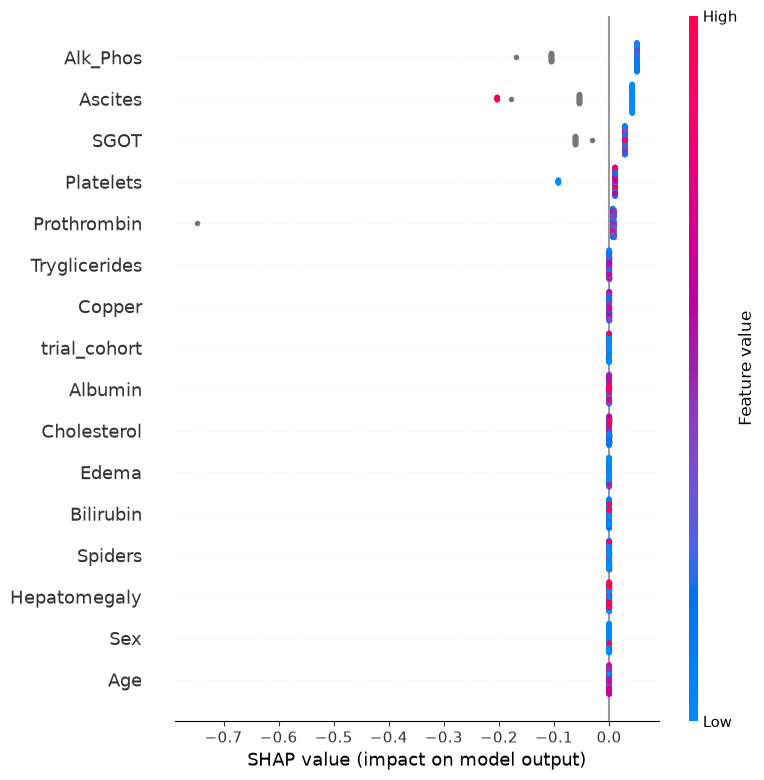

Wrote /home/datakrdo/Documents/portfolio/cirrhosis/outputs/notebook_shap_hist_gradient_boosting.png

Top mean |SHAP value| features:
     feature  importance
    Alk_Phos    0.064504
     Ascites    0.058150
        SGOT    0.036347
   Platelets    0.018683
 Prothrombin    0.016363
         Age    0.000000
         Sex    0.000000
Hepatomegaly    0.000000
 Cholesterol    0.000000
   Bilirubin    0.000000


In [5]:
import matplotlib.pyplot as plt

primary_pipeline = build_named_pipeline(PRIMARY_MODEL, split.X_train, random_state=41)
_, tuned_primary = select_operating_threshold(
    primary_pipeline, split.X_train, split.y_binary_train.to_numpy(), random_state=41
)
shap_result = compute_shap_explanations(
    tuned_primary.estimator_, split.X_train, split.X_test
)
plot_shap_summary(shap_result, shap_result.get("X", split.X_test), show=False)
fig_path = OUTPUT_DIR / "notebook_shap_hist_gradient_boosting.png"
plt.savefig(fig_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Wrote {fig_path}")
print("\nTop mean |SHAP value| features:")
print(shap_result["feature_importance_df"].head(10).to_string(index=False))

`hist_gradient_boosting` exposes neither `coef_` nor a single global
`feature_importances_` in the way `logistic`/`random_forest` do in
`02_modeling.ipynb`, so its explanation comes from SHAP's `TreeExplainer` on
the fold-fitted pipeline (`.estimator_`, since `TunedThresholdClassifierCV`
wraps the fitted pipeline rather than exposing it directly); category and
missing-value handling is native, matching what the model actually saw.

SHAP values describe association within this fitted model on this cohort, not
causal effect or individual clinical risk; a feature with a
structural-missingness pattern (see `01_eda.ipynb`) ranking highly likely
reflects cohort membership as much as biology.

SHAP is reported as a model-behaviour diagnostic and hypothesis generator
only; any high-ranked feature gets cross-checked against the
cohort/missingness finding before being interpreted clinically, and the plot
stays a supporting artifact rather than the notebook's headline claim.

In [6]:
single_split = {}
for name in MODELS:
    pipeline = build_named_pipeline(name, split.X_train, random_state=41)
    threshold, tuned = select_operating_threshold(
        pipeline, split.X_train, split.y_binary_train.to_numpy(), random_state=41
    )
    probabilities = tuned.predict_proba(split.X_test)[:, 1]
    single_split[name] = binary_metrics(split.y_binary_test.to_numpy(), probabilities, threshold=threshold)["auroc"]

comparison = pd.DataFrame({
    "single_split_auroc": single_split,
    "nested_cv_auroc_mean": {n: nested_results[n]["summary"]["auroc"]["mean"] for n in MODELS},
    "nested_cv_ci_low": {n: nested_results[n]["summary"]["auroc"]["ci_95"][0] for n in MODELS},
    "nested_cv_ci_high": {n: nested_results[n]["summary"]["auroc"]["ci_95"][1] for n in MODELS},
    "optimism_corrected_auroc": {n: optimism_results[n]["corrected"]["auroc"] for n in MODELS},
})
print("Single-split vs nested-CV vs optimism-corrected AUROC, all four models:")
print(comparison.round(3).to_string())

summary_path = OUTPUT_DIR / "model_development_summary.json"
summary_path.write_text(json.dumps({
    "comparison_auroc": comparison.round(4).to_dict(orient="index"),
    "hpo_best_params": study.best_params,
    "hpo_best_inner_cv_auroc": round(study.best_value, 4),
}, indent=2) + "\n")
print(f"\nWrote {summary_path}")

Single-split vs nested-CV vs optimism-corrected AUROC, all four models:
                        single_split_auroc  nested_cv_auroc_mean  nested_cv_ci_low  nested_cv_ci_high  optimism_corrected_auroc
logistic                             0.778                 0.701             0.612              0.814                     0.695
random_forest                        0.789                 0.697             0.579              0.816                     0.792
hist_gradient_boosting               0.740                 0.655             0.583              0.738                     0.738
lightgbm                             0.638                 0.687             0.556              0.785                     0.909

Wrote /home/datakrdo/Documents/portfolio/cirrhosis/outputs/model_development_summary.json


For `logistic`, all three estimators agree closely (~0.68-0.70 AUROC). For
the three tree-based models, they do not: nested-CV AUROC sits at 0.65-0.71
(with wide, overlapping CIs across all four models), while the
bootstrap-optimism-corrected AUROC is 0.90-0.91 — close to the near-1.0
apparent (in-sample) score minus a comparatively small estimated optimism.
Nested CV scores each fold on rows the model never saw during that fold's
fit; Harrell's bootstrap optimism correction instead fits on a bootstrap
resample and scores on the *original full training set*, which the resample
overlaps by construction (~63%) — for a high-capacity tree ensemble that can
nearly memorize 329 rows, that overlap likely lets the "apparent" score stay
inflated even after the optimism subtraction, understating true optimism.

A five- to six-fold difference in the estimated performance gap between two
textbook small-sample methods is itself the finding: neither a single split
nor a single resampling method should be trusted alone for a cohort this
size, and the disagreement gets disclosed rather than the more flattering
number quoted.

Nested CV is treated as the more conservative and trustworthy estimator for
the tree models here (true out-of-fold scoring, no train/score overlap); both
numbers are reported explicitly rather than picking one, and no model here
separates Stage 3-4 from Stage 1-2 well enough — under either estimator — to
support a clinical decision. `hist_gradient_boosting` remains the primary
comparator by design (native missingness handling), not because it wins this
table.

In [7]:
from src.evaluation import prediction_stability
from src.modeling import build_named_pipeline

stability_results = {}
for name in ("logistic", PRIMARY_MODEL):
    pipeline = build_named_pipeline(name, split.X_train, random_state=41)
    stability_results[name] = prediction_stability(
        pipeline, split.X_train, split.y_binary_train.to_numpy(), n_boot=200, random_state=41
    )

stability_table = pd.DataFrame({
    name: {
        "instability_mape": res["instability_mape"],
        "n_boot_valid": res["n_boot_valid"],
    }
    for name, res in stability_results.items()
}).T
print("Prediction instability (Riley & Collins 2023): bootstrap-refit vs original-fit "
      "predicted probability, mean absolute percentage error per patient, averaged:")
print(stability_table.round(3).to_string())

Prediction instability (Riley & Collins 2023): bootstrap-refit vs original-fit predicted probability, mean absolute percentage error per patient, averaged:
                        instability_mape  n_boot_valid
logistic                           0.147         329.0
hist_gradient_boosting             0.170         329.0


For each patient, 200 bootstrap-refit models predict a probability that
differs from the original model's prediction for that same patient; the mean
absolute percentage difference (`instability_mape`) summarizes how much an
individual's predicted risk would have moved had a slightly different
329-row sample been drawn. This is a direct, patient-level consequence of the
events-per-variable ~5.6 finding from `01_eda.ipynb` — low EPV predicts
exactly this instability.

A model whose risk estimate for the same patient swings substantially under
plausible resampling cannot be trusted for an individual-level decision, even
if its aggregate AUROC looks acceptable; stability is a separate axis from
discrimination and both must be reported.

Instability is reported alongside AUROC rather than in place of it; high
instability stands as further evidence, alongside the low EPV and the
apparent-vs-corrected AUROC gap, that this cohort size limits any
individual-level clinical claim.

In [8]:
# Why not XGBoost? Answered with this project's own evidence rather than by
# installing a fourth tree-based library.
xgb_evidence = pd.DataFrame({
    "apparent_auroc": {n: optimism_results[n]["apparent"]["auroc"] for n in ("random_forest", "hist_gradient_boosting", "lightgbm")},
    "nested_cv_auroc": {n: nested_results[n]["summary"]["auroc"]["mean"] for n in ("random_forest", "hist_gradient_boosting", "lightgbm")},
    "optimism_corrected_auroc": {n: optimism_results[n]["corrected"]["auroc"] for n in ("random_forest", "hist_gradient_boosting", "lightgbm")},
})
print("Existing tree-based comparators (apparent vs nested-CV vs optimism-corrected):")
print(xgb_evidence.round(3).to_string())
print(f"\nBest tree-based nested-CV AUROC: {xgb_evidence['nested_cv_auroc'].max():.3f}")
print(f"Tuned logistic nested-CV AUROC: {nested_results['logistic']['summary']['auroc']['mean']:.3f}")

Existing tree-based comparators (apparent vs nested-CV vs optimism-corrected):
                        apparent_auroc  nested_cv_auroc  optimism_corrected_auroc
random_forest                    0.897            0.697                     0.792
hist_gradient_boosting           0.834            0.655                     0.738
lightgbm                         1.000            0.687                     0.909

Best tree-based nested-CV AUROC: 0.697
Tuned logistic nested-CV AUROC: 0.701


Three members of the gradient-boosted-/bagged-tree family are already fit
above (`random_forest`, `hist_gradient_boosting`, `lightgbm`); all three reach
near-perfect apparent (in-sample) AUROC yet the whole class tops out at or
below the tuned logistic's nested-CV AUROC. A fourth tree implementation
would very likely reproduce the same pattern rather than break it.

With events-per-variable ~5.6, van der Ploeg, Austin & Steyerberg (2014,
*BMC Med Res Methodol*) show flexible learners need roughly 10x the EPV of
logistic regression (~200 vs ~10) to perform reliably, and Christodoulou
et al. (2019, *J Clin Epidemiol*) find no systematic ML-over-logistic-regression
advantage in clinical tabular prediction at realistic sample sizes — both
consistent with what this cohort's own numbers show.

XGBoost is not added as a dependency. The evidence for skipping it is this
project's own nested-CV/optimism-correction numbers plus the cited
literature, not an unsubstantiated preference for simpler models.